# Proyecto MLE - Riesgo Crediticio
## Fase 1: Entrenamiento y Evaluación de Modelos (Machine Learning)

En este notebook, utilizaremos los datos limpios de la fase anterior para entrenar modelos de clasificación que predigan la aprobación de un crédito (`LoanApproved`).

In [1]:
# 1. Importaciones base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Importaciones de Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Configuración visual
plt.style.use('seaborn-v0_8-darkgrid')

# 3. Cargar los datos limpios
# Asegúrate de que el nombre del archivo coincida con el que guardaste
df = pd.read_csv('../data/credit_risk_dataset_limpio.csv')

print(f"Dataset cargado exitosamente. Dimensiones: {df.shape}")

Dataset cargado exitosamente. Dimensiones: (5000, 15)


### 1.1 División de Datos y Escalado
Separaremos los datos en conjuntos de entrenamiento (80%) y prueba (20%). Luego, escalaremos las variables numéricas para que los modelos no le den más peso a variables grandes como `Income` sobre otras como `Age`.

In [2]:
# 1. Separar características (X) y variable objetivo (y)
X = df.drop('LoanApproved', axis=1)
y = df['LoanApproved']

# 2. Dividir en Entrenamiento y Prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Tamaño de Entrenamiento: {X_train.shape[0]} filas")
print(f"Tamaño de Prueba: {X_test.shape[0]} filas\n")

# 3. Escalar los datos
# Solo escalamos las variables numéricas continuas, NO las categóricas (One-Hot)
columnas_numericas = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience']

scaler = StandardScaler()
# Ajustamos (fit) solo con los datos de entrenamiento y transformamos ambos
X_train[columnas_numericas] = scaler.fit_transform(X_train[columnas_numericas])
X_test[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

# Mostramos un resumen para verificar el escalado
print("Media de X_train (debería ser muy cercana a 0):")
print(np.round(X_train[columnas_numericas].mean(), 2))

Tamaño de Entrenamiento: 4000 filas
Tamaño de Prueba: 1000 filas

Media de X_train (debería ser muy cercana a 0):
Age                0.0
Income            -0.0
LoanAmount         0.0
CreditScore        0.0
YearsExperience    0.0
dtype: float64


### 1.2 Entrenamiento y Evaluación de Modelos
Entrenaremos dos modelos distintos:
1.  **Regresión Logística:** Un modelo lineal interpretable.
2.  **Random Forest:** Un modelo basado en árboles, robusto y potente.

Evaluaremos su desempeño utilizando métricas de clasificación (Accuracy, Precision, Recall y F1-Score) y Matrices de Confusión.

--- Resultados de Regresión Logística ---
Exactitud (Accuracy): 0.8850
Precisión (Precision): 0.7805
Sensibilidad (Recall): 0.6957
F1-Score: 0.7356



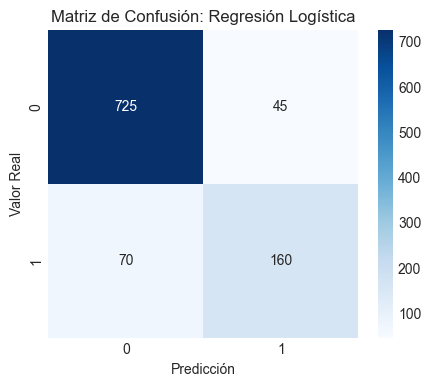

--------------------------------------------------
--- Resultados de Random Forest ---
Exactitud (Accuracy): 0.9640
Precisión (Precision): 0.9533
Sensibilidad (Recall): 0.8870
F1-Score: 0.9189



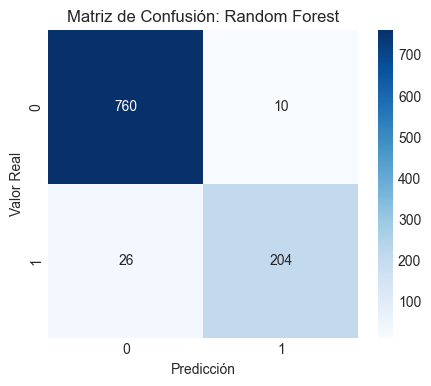

In [3]:
# Función auxiliar para evaluar modelos y no repetir código
def evaluar_modelo(modelo, X_test, y_test, nombre_modelo):
    y_pred = modelo.predict(X_test)
    
    print(f"--- Resultados de {nombre_modelo} ---")
    print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precisión (Precision): {precision_score(y_test, y_pred):.4f}")
    print(f"Sensibilidad (Recall): {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred):.4f}\n")
    
    # Matriz de Confusión Visual
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión: {nombre_modelo}')
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.show()

# 1. Entrenar y evaluar Regresión Logística
modelo_logistico = LogisticRegression(random_state=42)
modelo_logistico.fit(X_train, y_train)
evaluar_modelo(modelo_logistico, X_test, y_test, "Regresión Logística")

print("-" * 50)

# 2. Entrenar y evaluar Random Forest
modelo_rf = RandomForestClassifier(random_state=42, n_estimators=100)
modelo_rf.fit(X_train, y_train)
evaluar_modelo(modelo_rf, X_test, y_test, "Random Forest")

### 1.3 Validación Cruzada y Manejo de Desbalance
Para asegurar que nuestro modelo Random Forest no está sobreajustado y es estable, aplicaremos K-Fold Cross Validation (K=5). Además, añadiremos el parámetro `class_weight='balanced'` para penalizar los errores en la clase minoritaria (créditos aprobados), mitigando el desbalance natural de los datos.

In [4]:
from sklearn.model_selection import cross_val_score
import pickle
import os

# 1. Definimos el modelo final optimizado para el desbalance
modelo_final_rf = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    class_weight='balanced' # <-- Esto maneja el desbalance internamente
)

# 2. Aplicamos Cross-Validation (5 particiones) usando F1-Score
# cv=5 divide el train set en 5 partes, entrena en 4 y valida en 1, rotando.
scores_f1 = cross_val_score(modelo_final_rf, X_train, y_train, cv=5, scoring='f1')

print("--- Resultados de Validación Cruzada (K=5) ---")
print(f"F1-Scores en cada partición: {np.round(scores_f1, 4)}")
print(f"F1-Score Medio: {scores_f1.mean():.4f} (+/- {scores_f1.std() * 2:.4f})")

# 3. Entrenamos el modelo final con todo el set de entrenamiento
modelo_final_rf.fit(X_train, y_train)

print("\nModelo Final Entrenado Exitosamente.")

--- Resultados de Validación Cruzada (K=5) ---
F1-Scores en cada partición: [0.9239 0.9195 0.9444 0.9396 0.9382]
F1-Score Medio: 0.9331 (+/- 0.0193)

Modelo Final Entrenado Exitosamente.


In [5]:
# Guardar el modelo y el escalador en la carpeta artifacts
ruta_modelo = '../artifacts/modelo_rf_final.pkl'
ruta_scaler = '../artifacts/scaler.pkl'

with open(ruta_modelo, 'wb') as f:
    pickle.dump(modelo_final_rf, f)
    
with open(ruta_scaler, 'wb') as f:
    pickle.dump(scaler, f)

print(f"Artefactos guardados en:\n- {ruta_modelo}\n- {ruta_scaler}")

Artefactos guardados en:
- ../artifacts/modelo_rf_final.pkl
- ../artifacts/scaler.pkl


## Fase 2: Integración de LLMs (Explainable AI)

Aunque los modelos de Machine Learning tradicionales como Random Forest son muy precisos, suelen operar como "cajas negras". Para agregar valor al negocio, integraremos la API de **Google Gemini** para generar explicaciones en lenguaje natural sobre las decisiones tomadas por nuestro modelo de clasificación.

In [ ]:
import google.generativeai as genai
import os
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')

# Cargar las variables ocultas del archivo .env
load_dotenv()
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
genai.configure(api_key=GOOGLE_API_KEY)

# Inicializar el modelo
llm_model = genai.GenerativeModel('gemini-1.5-flash')

# 2. Seleccionar un "cliente" de prueba de nuestro X_test
indice_cliente = 0
cliente_datos = X_test.iloc[indice_cliente]
cliente_datos_originales = df.iloc[X_test.index[indice_cliente]] # Para ver los datos sin escalar

# 3. Hacer la predicción con el modelo de Machine Learning que entrenamos arriba
prediccion = modelo_final_rf.predict(X_test.iloc[[indice_cliente]])[0]
resultado_str = "APROBADO" if prediccion == 1 else "RECHAZADO"

# 4. Crear el Prompt Engineering para el LLM
prompt = f"""
Actúa como un experto analista de riesgo crediticio. 
Nuestro modelo de Machine Learning ha evaluado a un cliente y ha decidido que su crédito sea: {resultado_str}.

Aquí están los datos clave del solicitante:
- Edad: {cliente_datos_originales['Age']} años
- Ingresos Anuales: ${cliente_datos_originales['Income']}
- Monto del Préstamo Solicitado: ${cliente_datos_originales['LoanAmount']}
- Puntaje Crediticio (Credit Score): {cliente_datos_originales['CreditScore']}
- Años de Experiencia Laboral: {cliente_datos_originales['YearsExperience']}

Con base en estos datos, redacta un párrafo corto (máximo 4 líneas) explicando de forma profesional a la gerencia por qué tiene sentido esta decisión automática. No menciones el Machine Learning, enfócate en el perfil financiero.
"""

# 5. Llamar a la API y mostrar la respuesta
print(f"--- Decisión del Modelo ML: {resultado_str} ---\n")
print("Explicación generada por Gemini AI:")
try:
    respuesta = llm_model.generate_content(prompt)
    print(respuesta.text)
except Exception as e:
    print(f"Error al conectar con la API: {e}")